<h2> Nauczanie maszynowe/Ćwiczenia9

* 09.12.2025, Jadwiga Krząstek

Zagadnienia na dziś:
- Algorytmy grupowania, w szczególności k-means oraz DBSCAN
- wybór optymalnej liczby grup - kryteria
- grupowanie górskie, grupowanie Gustafsona-Kessela
- GMM i możliwość generowania danych
- grupowanie hierarchiczne

<h4> Zadanie1 (1pkt): Rozważ dane dotyczące mikrobiomu roślinnego. Dokładniej:
    
- plik otuTable97.txt zawiera informacje o liczbie odczytów przypadających na dany OTU (gatunek lub grupa blisko spokrewnionych gatunków bakterii) w danej próbce; uwaga: podobnie jak w danych z sekwencjowania, próbki znajdują się w kolumnach
- plik SMD.txt zawiera metadane dotyczące próbek, gdzie występuje m.in. kolumna Type określająca miejsce pobrania próbki: root (korzeń), leaf (liść) oraz soil (sama gleba, nie związana bezpośrednio z korzeniem)

Co trzeba zrobić?

- otwórz plik otuTable97.txt, podaj rozmiar danych
- dokonaj transpozycji danych
- dokontaj tzw. normalizacji CLR (centred log-ratio tranformation): zastosuj operację $\log(x+1)$, następnie odejmij od wartości średnią w kolumnie.
- wykonaj PCA(2), jaki procent wariancji objaśniamy za pomocą pierwszych dwóch komponent?
- wykonaj algorytm k-means z $k=2$ oraz $k=3$ na pełnym zbiorze danych oraz zredukowanych od dwóch cech - porównaj wyniki (wystarczy ocena wizualna na zredukowanych danych).
- narysuj wykres PCA2 vs PCA1, kolorując próbki wg kolumny Type z pliku SMD.txt, czy te grupy (przynajmniej częściowo) pokrywają się z którymś przypadkiem z poprzedniego zadania? Wystarczy ocena wizualana i komentarz :).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [3]:
table = pd.read_csv("otuTable97.txt", sep="\t", header=0, index_col=0)
table_T = table.T
print(table_T.shape)

(1698, 47806)


In [4]:
table_T.head()

OTU_ID,1,2,3,4,5,6,7,8,9,10,...,47797,47798,47799,47800,47801,47802,47803,47804,47805,47806
M1024P1833,0.0,41.0,67.0,3229.0,1200.0,219.0,485.0,840.0,40.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M1551P81,0.0,22.0,65.0,13679.0,92.0,1980.0,5123.0,7079.0,82.0,79.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M1551P57,0.0,4.0,12.0,1832.0,3530.0,1200.0,755.0,3760.0,91.0,277.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
M1551P85,0.0,726.0,13514.0,951.0,2008.0,499.0,4080.0,22.0,881.0,2879.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M1551P28,0.0,112492.0,1.0,113.0,0.0,1.0,443.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0


In [7]:
table_log = table_T.copy()
table_log = np.log1p(table_log)
print(table_log.head())

OTU_ID      1          2         3         4         5         6      \
M1024P1833    0.0   3.737670  4.219508  8.080237  7.090910  5.393628   
M1551P81      0.0   3.135494  4.189655  9.523690  4.532599  7.591357   
M1551P57      0.0   1.609438  2.564949  7.513709  8.169336  7.090910   
M1551P85      0.0   6.588926  9.511555  6.858565  7.605392  6.214608   
M1551P28      0.0  11.630646  0.693147  4.736198  0.000000  0.693147   

OTU_ID         7         8         9         10     ...  47797  47798  \
M1024P1833  6.186209  6.734592  3.713572  2.484907  ...    0.0    0.0   
M1551P81    8.541691  8.865029  4.418841  4.382027  ...    0.0    0.0   
M1551P57    6.628041  8.232440  4.521789  5.627621  ...    0.0    0.0   
M1551P85    8.314097  3.135494  6.782192  7.965546  ...    0.0    0.0   
M1551P28    6.095825  0.000000  0.693147  0.693147  ...    0.0    0.0   

OTU_ID         47799  47800  47801  47802  47803     47804     47805  47806  
M1024P1833  0.000000    0.0    0.0    0.0    0.0  

In [9]:
table_T = table.T
table_T = table_T.astype(float)

table_log = np.log1p(table_T)  # DataFrame -> numpy array-like, ale zachowuje index/columns jeśli użyjesz pandas op
table_log = pd.DataFrame(table_log, index=table_T.index, columns=table_T.columns)

table_clr = table_log.sub(table_log.mean(axis=1), axis=0)  # axis=0 => align by index (wiersze)
# teraz table_clr: samples x OTUs, z wartościami zcenterowanymi per-sample

print("CLR shape:", table_clr.shape)
print("Przykładowe wiersze (po CLR):")
print(table_clr.iloc[:3, :5])

CLR shape: (1698, 47806)
Przykładowe wiersze (po CLR):
OTU_ID             1         2         3         4         5
M1024P1833 -0.151284  3.586386  4.068224  7.928954  6.939626
M1551P81   -0.161228  2.974266  4.028426  9.362462  4.371371
M1551P57   -0.151918  1.457519  2.413031  7.361791  8.017418


In [11]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(table_clr)
explained = pca.explained_variance_ratio_
print("Wariancja [PC1, PC2]:", explained)
print("Suma wariancji 2 PC:", explained.sum())

Wariancja [PC1, PC2]: [0.21910238 0.09367457]
Suma wariancji 2 PC: 0.3127769524476761


In [13]:
pcs_df = pd.DataFrame(pcs, index=table_clr.index, columns=["PC1","PC2"])
meta = pd.read_csv("SMD.txt", sep="\t", header=0, index_col=None)
print(meta.columns.tolist())

['SampleID', 'Name', 'Plant_ID', 'Type', 'Experiment', 'Cohort', 'Harvested', 'Age', 'Site', 'Treatment', 'Line', 'Genotype', 'Block', 'oldPlate', 'newPlate', 'Analysis']


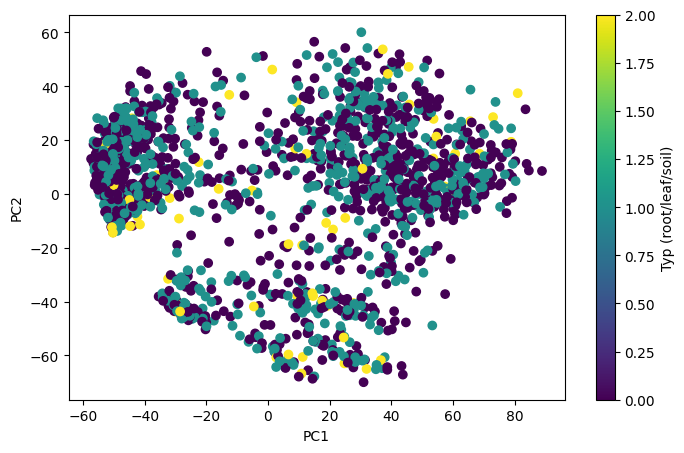

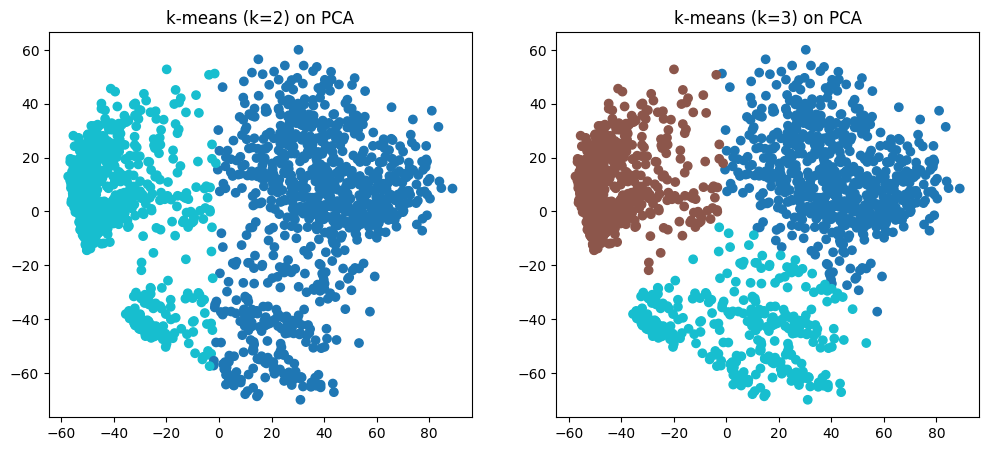

In [23]:
pca_2d = pca.fit_transform(table_clr)
plt.figure(figsize=(8,5))
plt.scatter(pcs[:,0], pcs[:,1],
            c=meta["Type"].map({"root":0, "leaf":1, "soil":2}),
            cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Typ (root/leaf/soil)")
plt.show()

#K-means na pełnych danych
k2_full = KMeans(n_clusters=2, random_state=0).fit(table_clr)
k3_full = KMeans(n_clusters=3, random_state=0).fit(table_clr)

#K-means na PCA(2)
k2_pca = KMeans(n_clusters=2, random_state=0).fit(pca_2d)
k3_pca = KMeans(n_clusters=3, random_state=0).fit(pca_2d)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(pca_2d[:,0], pca_2d[:,1], c=k2_pca.labels_, cmap='tab10')
plt.title("k-means (k=2) on PCA")

plt.subplot(1,2,2)
plt.scatter(pca_2d[:,0], pca_2d[:,1], c=k3_pca.labels_, cmap='tab10')
plt.title("k-means (k=3) on PCA")

plt.show()

<h4> Zadanie2B (2pkt): Zaimplementuj algorytm Gustafsona-Kessela. Zastosuj go do poniższych danych - algorytm powinien sobie poradzić z poprawną klasyfikacją.


* UWAGA: działanie może być (i pewnie będzie) uzależnione od warunków początkowych - warto uruchomić kod kilkakrotnie.

- zacznijcie od definicji tej odległości Mahalanobisa, argumentami funkcji niech będą: "A, x, c" z tym ze A to macierz 2x2, x,y to wektory 2D; zwróćcie uwagę czy mnożenie jest dobrze wykonywane, przeliczcie sobie na kartce nawet jakiś przykład --> wynikiem powinna być oczywiście liczba
- początkowe macierze A przyjmujemy jako jednostkowe, można napisać ręcznie lub np.identity(2)
- jako "m" przyjmijcie 2 lub 3 ale można tez testować (hiperparametr)
- wartości u_ij najlepiej przechowywać w macierzy, początkowo można sobie wygenerować jakąs losową o zadanym rozmiarze, macierz typu U = np.random.randn(3,4)
- przy liczeniu Si (wzór 13.45) wynikiem powinna być macierz 2x2, mnożymy dwa wektory 2D, można bawic się z tranpozycjami + metoda np.dot(a,b) lub użyć metodę np.outer(a,b)
 

In [12]:
def mahalanobis_distance1(A, x, c): #13.42
    diff = x - c
    tmp = np.dot(diff, A)                  # (N,d) @ (d,d) → (N,d),to samo co diff @ A
    val = np.sum(tmp * diff, axis=1)       # suma elementów — skalar per punkt, to samo co sum(tmp * diff)

    return np.sqrt(val)

def mahalanobis_distance(A, x, c):
    A = np.array(A, dtype=float)
    x = np.array(x, dtype=float).reshape(-1)
    c = np.array(c, dtype=float).reshape(-1)

    diff = x - c

    tmp = np.dot(diff, A) 
    val = np.dot(tmp, diff)

    val = float(np.clip(val, 0.0, None)) #clip potrzebne - zaokrąglenia na macierzach mogą powodować pojawienie się liczb ujemnych
    return np.sqrt(val)


(przykładowe wartości do testowania czy odległość działa)

In [14]:
A = np.eye(2)
c = [1, 2]
x = [4, 5]
print("Test1 d =", mahalanobis_distance(A, x, c))   #oczekiwane: sqrt(3^2 + 3^2) = sqrt(18) ≈ 4.242640687


Test1 d = 4.242640687119285


mahalanobis_distance działa

In [54]:
#wybor losowych punktów, K = liczba klastrów, N = liczba punktów 
def init_U(N, K, random_state=None): 
    rng = np.random.RandomState(random_state)
    U = rng.rand(K, N)
    U /= U.sum(axis=0, keepdims=True)
    return U

def gk_clustering(X, K=3, m=2.0, max_iter=100, tol=1e-5, reg=1e-6,
                  random_state=0):
    N, d = X.shape #d - stopnien pierwiastka
    #1. inicjalizacja położeń centrów
    U = init_U(N, K, random_state=random_state) 
    eps = 1e-8

    for it in range(max_iter):
        U_prev = U.copy()

        #3. centra wzor 13.44
        um = U ** m
        c = (um @ X) / (um.sum(axis=1, keepdims=True) + eps)

        #4. macierze kowariancji Si 13.45
        S_list = []
        A_list = []
        for i in range(K):
            #różnice licznik
            diffs = X - c[i]
            denom = um[i].sum()#+ eps #mianownik
            #licznik / mianownik
            S = (um[i][:, None] * diffs).T @ diffs / denom
            S_list.append(S)
            #5. A_i = |S|^{1/d} * inv(S) 13.46
            detS = np.linalg.det(S)
            #zabezpieczenie zerowania się detS
            if detS <= 0:
                invS = np.linalg.pinv(S)
                scale = 1.0
            else:
                invS = np.linalg.inv(S)
                scale = detS ** (1.0 / d)
            invS = np.linalg.inv(S)
            scale = detS ** (1.0 / d) #zamiast pierwiastka o stopniu N potęgujemy do 1/N
            A = scale * invS
            A_list.append(A)

        #odległości d_{ij} 13.42
        D = np.zeros((K, N))
        for i in range(K):
            D[i] = mahalanobis_distance(A_list[i], X, c[i]) + eps

        #2. macierz współczynników przynależności 13.43
        #u_ij = 1 / sum_k (d_ij / d_kj)^{2/(m-1)}
        power = 2.0 / (m - 1.0) #potęga
        D_ratio = (D[:, :, None] / D[:, None, :])
        #u[:,j] = 1 / sum_k (D[:,j] / D[k,j])**power
        U_new = np.zeros_like(U)
        for j in range(N):
            dj = D[:, j]  # (K,)
            ratios = (dj[:, None] / dj[None, :]) ** power
            denom = ratios.sum(axis=1)
            U_new[:, j] = 1.0 / denom

        U_new = np.clip(U_new, 1e-8, 1.0)
        U_new /= U_new.sum(axis=0, keepdims=True)

        U = U_new

        #6. zatrzymanie pętli
        max_change = np.max(np.abs(U - U_prev))
        if max_change < tol:
            print(f"converged at iter {it}, max_change {max_change:.3e}")
            break

    return {
        'U': U,
        'centers': c,
        'A_list': A_list,
        'S_list': S_list,
        'D': D
    }

converged at iter 15, max_change 3.728e-06


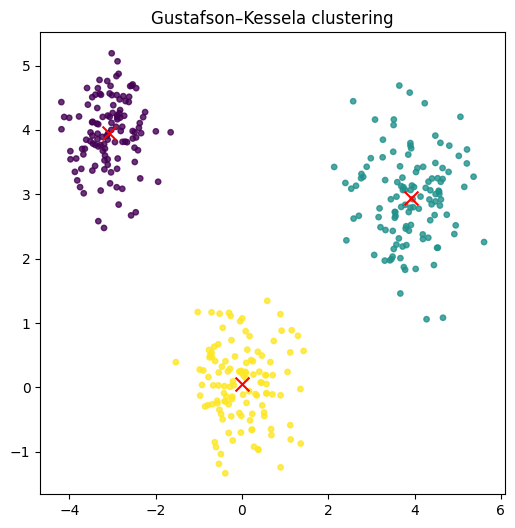

In [55]:
if __name__ == "__main__":
    rng = np.random.RandomState(0)
    X1 = rng.normal(loc=[0,0], scale=0.6, size=(120,2))
    X2 = rng.normal(loc=[4,3], scale=0.7, size=(120,2))
    X3 = rng.normal(loc=[-3,4], scale=0.5, size=(120,2))
    X = np.vstack([X1,X2,X3])

    res = gk_clustering(X, K=3, m=2.0, max_iter=100, tol=1e-5, random_state=1)

    U = res['U']
    c = res['centers']
    labels = U.argmax(axis=0)

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=15, alpha=0.8)
    plt.scatter(c[:,0], c[:,1], c='red', marker='x', s=100)
    plt.title("Gustafson–Kessela clustering")
    plt.show()


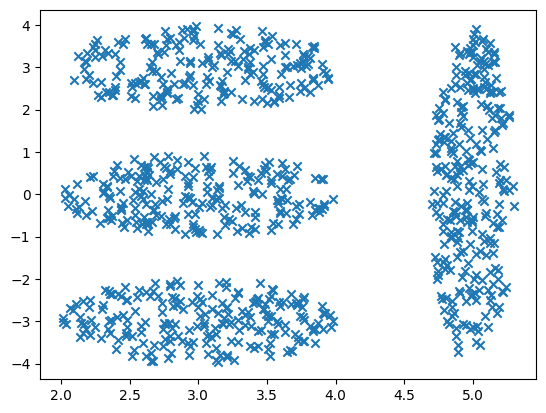

In [56]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000
x = np.random.uniform(-6, 6, n)
y = np.random.uniform(-6, 6, n)

x1 = []
y1 = []
for i in range(n):
    if ((x[i]-5)**2)/0.3**2+((y[i]-0)**2)/4**2 <=1 or ((x[i]-3)**2)/1**2+((y[i]-3)**2)/1**2 <=1 or ((x[i]-3)**2)/1**2+((y[i]-0)**2)/1**2 <=1 or ((x[i]-3)**2)/1**2+((y[i]+3)**2)/1**2 <=1:
        x1.append(x[i])
        y1.append(y[i])
X1 = np.array([[x,y] for (x,y) in zip(x1,y1)])

plt.scatter(X1[:,0],X1[:,1], marker = "x")
plt.show()

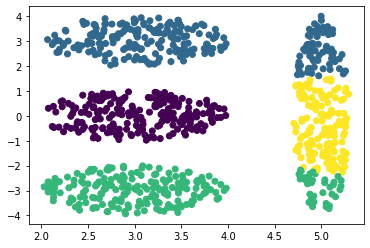

In [40]:
#dla porownania K-means, ktory ma problem z tego typu danymi (ksztaltami)
kmeans = KMeans(n_clusters=4)
kmeans.fit(X);
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show() 

converged at iter 22, max_change 8.519e-06


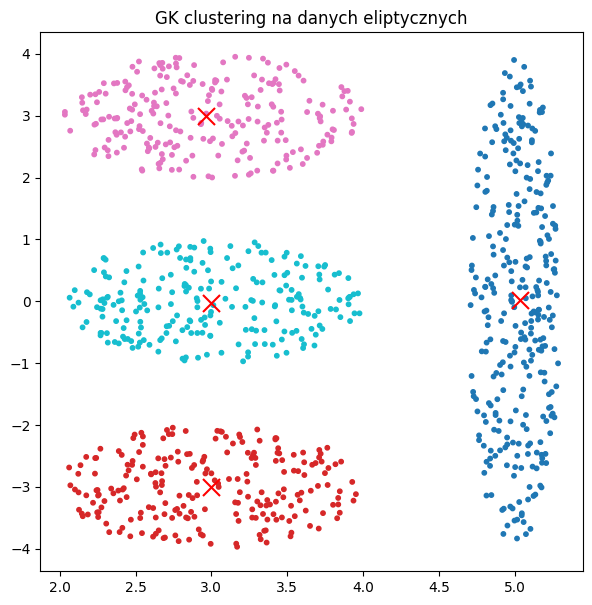

'\nplt.figure(figsize=(6,6))\nplt.scatter(X1[:,0], X1[:,1], c=labels, cmap=\'viridis\', s=15, alpha=0.8)\nplt.scatter(c[:,0], c[:,1], c=\'red\', marker=\'x\', s=100)\nplt.title("Gustafson–Kessela clustering")\nplt.show()'

In [63]:
res = gk_clustering(X1, K=4, m=2.0, max_iter=100, tol=1e-5, random_state=1)

U = res['U']
centers = res['centers']
labels = U.argmax(axis=0)

plt.figure(figsize=(7,7))
plt.scatter(X1[:,0], X1[:,1], c=labels, cmap="tab10", s=10)
plt.scatter(centers[:,0], centers[:,1], c='red', marker='x', s=150)
plt.title("GK clustering na danych eliptycznych")
plt.show()

#### **Komentarz**: zaimplementowany algorytm radzi sobie lepiej niż k-means :)

<h4> Zadanie3 (1pkt): Rozważ sekwencje nukleotydowe (training_set) wybranych wirusow należących do 6. grup. 
    
- narysuj histogram rozkładu długości sekwencji
- zastanów się nad reprezentacją tych sekwencji: k-mery? jakie $k$?
- wykonaj algorytm k-means z $k=6$, zaprezentuj wyniki na zredukowanej przestrzeni za pomocą $PCA(2)$. Porównaj te wyniki podanymi typami.
- potestuj metody grupowania hierarchicznego na tym zbiorze. Czy obserwujesz naturalne nadrgupy?

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
from collections import Counter
from sklearn.cluster import KMeans

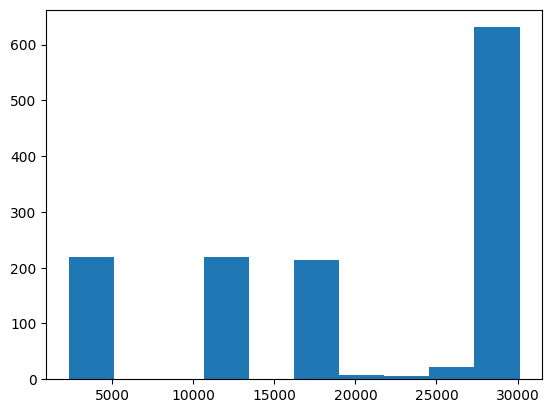

In [67]:
df = pd.read_csv('training_set.csv')
df['length'] = df['Sequence'].str.len()
df.head()

plt.hist(df['length'])
plt.show()

#### Przetestujmy kilka k i wybierzmy najlepsze (dokładność+szybkość obliczeń)

In [69]:
#generujemy wszystkie możliwe k-mery
def all_kmers(k):
    alphabet = ['A','C','G','T']
    return [''.join(p) for p in product(alphabet, repeat=k)]

#liczymy częstości k-merów w jednej sekwencji
def kmer_counts(seq, k, kmer_list):
    counts = Counter(seq[i:i+k] for i in range(len(seq)-k+1))
    return np.array([counts[km] for km in kmer_list])

#tworzymy macierz cech
def build_kmer_matrix(sequences, k):
    kmer_list = all_kmers(k)
    X = np.vstack([kmer_counts(seq, k, kmer_list) for seq in sequences])
    return X, kmer_list


#### Weźmy może k = [3,4,5]

In [71]:
for k in [3,4,5]:
    X_kmer, _ = build_kmer_matrix(df["Sequence"], k)
    print(k, X_kmer.shape)


3 (1320, 64)
4 (1320, 256)
5 (1320, 1024)


#### **Komentarz**
Im większe k, tym więcej cech ma wartość 0. Staje się to problematyczne w k-means dla dużych k. PCA i k-means będą działać najlepiej dla 64 lub 256 cech (k = [3, 4]). Mamy więc:
- k <= 3 - za mała różnorodność
- k >= 5 - dużo wolniejsze obliczenia i bardziej podatne na szum
- k = 4 - najbardziej optymalne.

Wariancja:  [0.85841938 0.05962607]


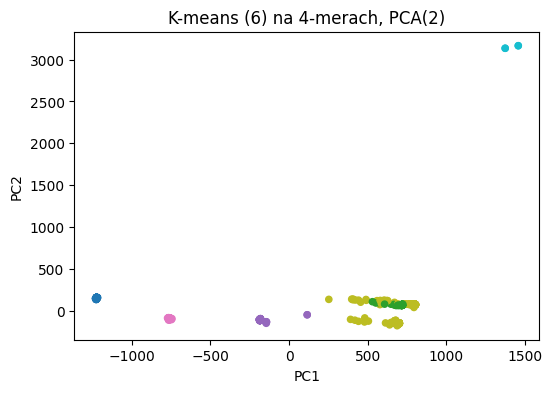

In [81]:
k = 4 #nasz wybór
X_kmer, _ = build_kmer_matrix(df["Sequence"], k)

#K-means (k=6)
kmeans = KMeans(n_clusters=6, random_state=0)
labels_pred = kmeans.fit_predict(X_kmer)

#PCA(2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_kmer)

print("Wariancja: ", pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pred, s=20, cmap='tab10')
plt.title("K-means (6) na 4-merach, PCA(2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

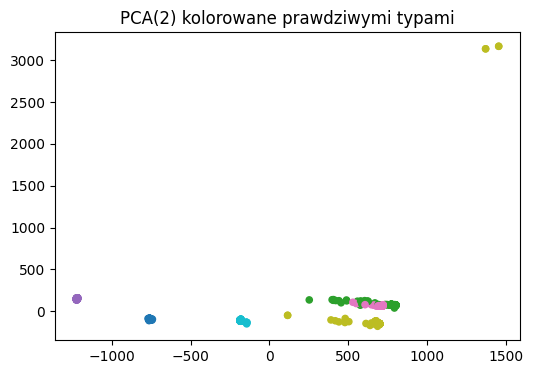

In [82]:
true_types = df["Type"]

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=pd.factorize(true_types)[0],
            cmap='tab10', s=20)
plt.title("PCA(2) kolorowane prawdziwymi typami")
plt.show()


#### **Podsumowanie**:
Reprezentacja 4-merowa połączona z grupowaniem k-means zadziałała bardzo dobrze dla analizowanych danych. Na wykresach są widocznie wyraźnie oddzielone grupy sekwencji. Dodatkowo, grupowanie w całości odpowiada prawdziwym klasom.